# QENS Benzene Analysis 




In [1]:
import os
import json
import warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, LinearSegmentedColormap
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit, nnls, minimize
from scipy.signal import fftconvolve

warnings.filterwarnings('ignore')

In [2]:
# make sure that all nxspe files should sit next to this notebook

DATA_DIR = os.path.dirname(os.path.abspath('__file__'))
SAVE_DIR = os.path.join(DATA_DIR, 'results')
os.makedirs(SAVE_DIR, exist_ok=True)

In [3]:
N_DET  = 249        # detector groups
N_BIN  = 320        # energy bins
OFF_E   = 0x30c0    # byte offset: energy edges
OFF_D   = 0x41b8    # byte offset: S(Q,w) data
OFF_ERR = 0x9fbb8   # byte offset: errors

In [ ]:
# angles run 3.5 -> 140 degrees across 249 groups

TWO_THETA = np.linspace(3.5, 140.0, N_DET)

In [22]:
# physical constants

mn    = 1.6749e-27     # neutron mass, kg
hbar  = 1.0546e-34     # J.s
meV_J = 1.6022e-22     # 1 meV in joules
HBAR  = 0.6582         # hbar in meV.ps — used in all model equations

print('setup done, saving to:', SAVE_DIR)


setup done, saving to: /Users/shubhamshinde/Desktop/QENS Analysis/results


In [ ]:
def read_nxspe(path):

    """
    Read a .nxspe file. Returns a plain dict with numpy arrays.
    
    """

    name  = os.path.basename(path)
    parts = name.replace('.nxspe', '').split('_')
    T    = int(parts[1])
    Ei   = int(parts[2]) / 100.0  # '360' -> 3.60 meV
    kind = parts[3]         # 'inc' or 'coh'



    with open(path, 'rb') as f:
        raw = f.read()

    edges = np.frombuffer(raw[OFF_E : OFF_E + (N_BIN+1)*8], dtype='<f8')
    e_raw = 0.5 * (edges[:-1] + edges[1:])



    n    = N_DET * N_BIN
    data = np.frombuffer(raw[OFF_D   : OFF_D   + n*8], dtype='<f8').reshape(N_DET, N_BIN).copy()
    errs = np.frombuffer(raw[OFF_ERR : OFF_ERR + n*8], dtype='<f8').reshape(N_DET, N_BIN).copy()


    good = np.array([np.sum(np.isfinite(data[i]) & (data[i] > 0)) > N_BIN // 2
        for i in range(N_DET)])


    ki = np.sqrt(2 * mn * Ei * meV_J) / hbar * 1e-10  # Angstrom^-1
    Q  = 2 * ki * np.sin(np.radians(TWO_THETA / 2))



    return dict(name=name, T=T, Ei=Ei, kind=kind,
                e_raw=e_raw, data=data, errs=errs,
                good=np.where(good)[0], Q=Q)

In [ ]:
def read_nxspe(path):

    """
    Read a Pelican .nxspe file. Returns a plain dict with numpy arrays."""
    name  = os.path.basename(path)
    parts = name.replace('.nxspe', '').split('_')
    T    = int(parts[1])
    Ei   = int(parts[2]) / 100.0  
    kind = parts[3]        


    with open(path, 'rb') as f:
        raw = f.read()


    edges = np.frombuffer(raw[OFF_E : OFF_E + (N_BIN+1)*8], dtype='<f8')
    e_raw = 0.5 * (edges[:-1] + edges[1:])


    n    = N_DET * N_BIN
    data = np.frombuffer(raw[OFF_D   : OFF_D   + n*8], dtype='<f8').reshape(N_DET, N_BIN).copy()
    errs = np.frombuffer(raw[OFF_ERR : OFF_ERR + n*8], dtype='<f8').reshape(N_DET, N_BIN).copy()


    good = np.array([np.sum(np.isfinite(data[i]) & (data[i] > 0)) > N_BIN // 2 
                     for i in range(N_DET)])


    ki = np.sqrt(2 * mn * Ei * meV_J) / hbar * 1e-10  
    Q  = 2 * ki * np.sin(np.radians(TWO_THETA / 2))

    return dict(name=name, T=T, Ei=Ei, kind=kind,
                e_raw=e_raw, data=data, errs=errs,
                good=np.where(good)[0], Q=Q)

In [ ]:
def fit_elastic_peak(d):
    """
    Fit a Gaussian to the elastic peak (averaged over lowest-Q detectors)
    to measure the energy offset E0.

    The width we get here is NOT the instrument resolution for INC files —
    INC peaks are broadened by QENS. We fix that in the next cell.
    
    """

    good   = d['good']
    n_low  = max(3, len(good) // 7)  
    e      = d['e_raw']


    avg = np.nanmean([d['data'][i] for i in good[:n_low]], axis=0)
    avg = np.where(np.isfinite(avg), avg, 0)


    def gauss(x, A, mu, sig, bg):
        return A * np.exp(-0.5 * ((x - mu) / sig)**2) + bg


    pk = np.argmax(avg)
    try:
        popt, _ = curve_fit(gauss, e, avg,
                            p0=[avg[pk], e[pk], 0.05, avg.min()],
                            bounds=([-np.inf, e[0], 1e-4, -np.inf], [np.inf, e[-1], 2.0, np.inf]),
                            maxfev=8000)
        E0, sig_raw = popt[1], abs(popt[2])


    except:
        E0, sig_raw = e[pk], 0.043  # fallback if fit fails



    d['E0']      = E0
    d['sig_raw'] = sig_raw
    d['e']       = e - E0  # corrected energy axis used everywhere else
    return E0, sig_raw


In [ ]:
all_files = ['benzene_260_360_inc.nxspe','benzene_290_124_coh.nxspe', 'benzene_290_124_inc.nxspe',
             'benzene_290_197_coh.nxspe', 'benzene_290_197_inc.nxspe','benzene_290_360_coh.nxspe', 
             'benzene_290_360_inc.nxspe','benzene_290_861_coh.nxspe', 'benzene_290_861_inc.nxspe']



ds = {}  # all loaded datasets, keyed by filename


print(f"{'file':<42} {'Ei':>5}  {'E0 (meV)':>10}  {'raw FWHM (ueV)':>15}")


for fname in all_files:
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        print(f'  MISSING: {fname}')
        continue

    d = read_nxspe(path)

    fit_elastic_peak(d)

    ds[fname] = d

    print(f"  {fname:<42} {d['Ei']:>5.2f}  {d['E0']:>+10.4f}  {d['sig_raw']*2355:>15.1f}")

file                                          Ei    E0 (meV)   raw FWHM (ueV)
  benzene_260_360_inc.nxspe                   3.60     +0.5974            109.0
  benzene_290_124_coh.nxspe                   1.24     +0.2102             27.8
  benzene_290_124_inc.nxspe                   1.24     +0.2087             50.3
  benzene_290_197_coh.nxspe                   1.97     -1.2460            101.3
  benzene_290_197_inc.nxspe                   1.97     -1.2657            101.3
  benzene_290_360_coh.nxspe                   3.60     +0.5943             90.0
  benzene_290_360_inc.nxspe                   3.60     +0.5967            227.7
  benzene_290_861_coh.nxspe                   8.61     +1.4894            467.1
  benzene_290_861_inc.nxspe                   8.61     +1.4534            964.1


In [ ]:
coh_sigma = {d['Ei']: d['sig_raw'] for d in ds.values() if d['kind'] == 'coh'}



for d in ds.values():
    if d['Ei'] in coh_sigma:
        d['sigma_res'] = coh_sigma[d['Ei']]
        
    else:
        d['sigma_res'] = d['sig_raw']  # no COH twin — fall back
        print(f"  no COH file for Ei={d['Ei']:.2f}, using raw sigma (may be inflated)")
    d['fwhm_res'] = 2.355 * d['sigma_res']



print('\nCOH-based resolution:')
for Ei, s in sorted(coh_sigma.items()):
    print(f'  Ei={Ei:.2f} meV  FWHM={s*2355:.1f} ueV')



# shortcuts used throughout the rest of the notebook
d_inc = ds['benzene_290_360_inc.nxspe']  # main analysis target
d_coh = ds['benzene_290_360_coh.nxspe']  # resolution reference



print(f"\nPrimary: {d_inc['name']}")
print(f"  Q:    {d_inc['Q'][d_inc['good']].min():.2f} - {d_inc['Q'][d_inc['good']].max():.2f} A^-1")
print(f"  res:  {d_inc['fwhm_res']*1000:.1f} ueV FWHM (from COH)")



COH-based resolution:
  Ei=1.24 meV  FWHM=27.8 ueV
  Ei=1.97 meV  FWHM=101.3 ueV
  Ei=3.60 meV  FWHM=90.0 ueV
  Ei=8.61 meV  FWHM=467.1 ueV

Primary: benzene_290_360_inc.nxspe
  Q:    0.56 - 2.25 A^-1
  res:  90.0 ueV FWHM (from COH)


# quick look at all datasets — just the elastic region, normalised

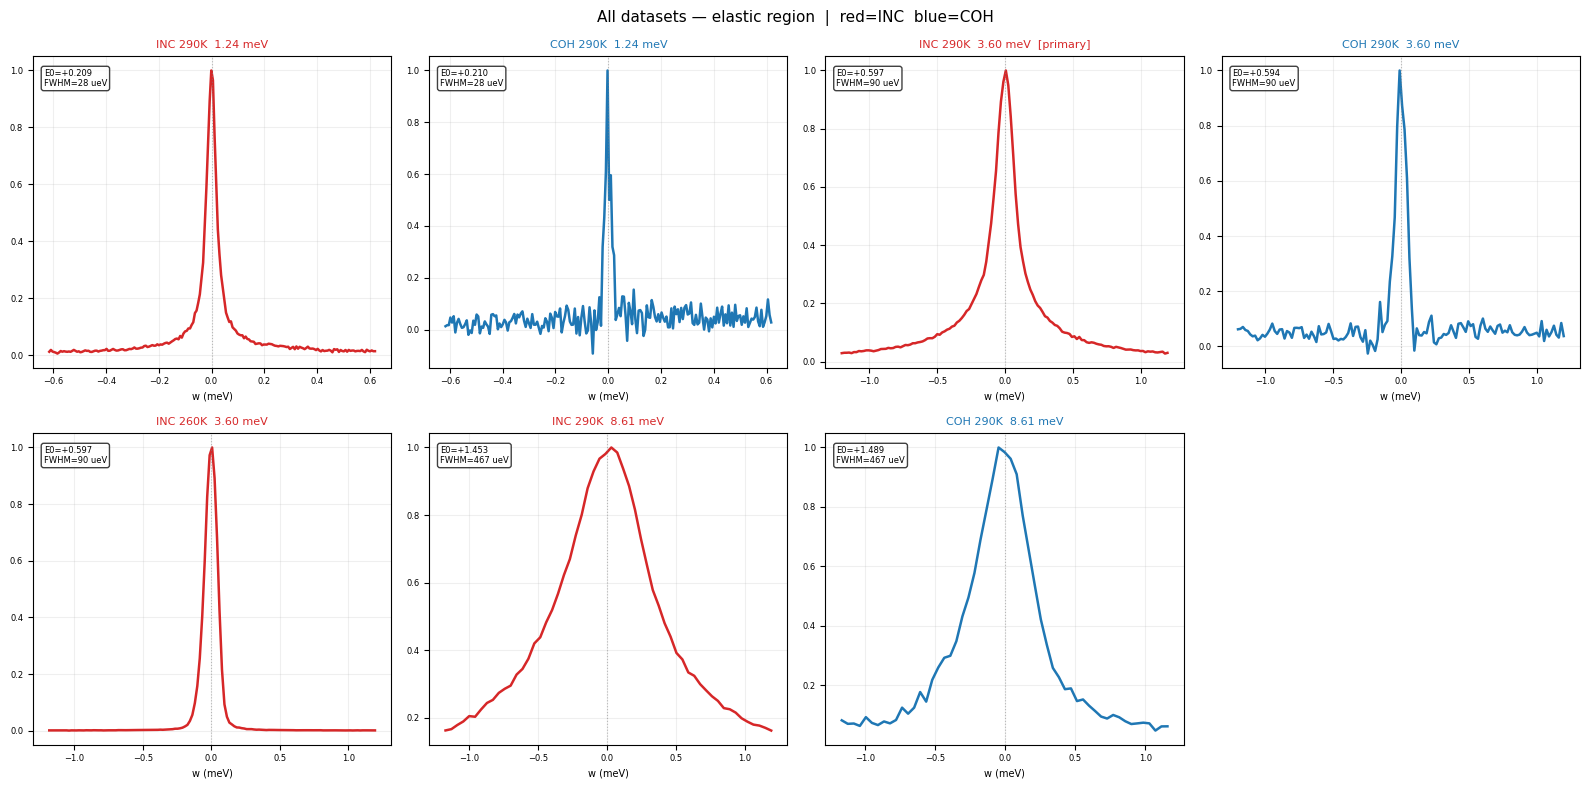

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))


axes = axes.flatten()


plot_order = [('benzene_290_124_inc.nxspe', 'INC 290K  1.24 meV'),
              ('benzene_290_124_coh.nxspe', 'COH 290K  1.24 meV'),
              ('benzene_290_360_inc.nxspe', 'INC 290K  3.60 meV  [primary]'),
              ('benzene_290_360_coh.nxspe', 'COH 290K  3.60 meV'),
              ('benzene_260_360_inc.nxspe', 'INC 260K  3.60 meV'),
              ('benzene_290_861_inc.nxspe', 'INC 290K  8.61 meV'),
              ('benzene_290_861_coh.nxspe', 'COH 290K  8.61 meV'),]



for ax, (fname, label) in zip(axes, plot_order):

    if fname not in ds:
        ax.text(0.5, 0.5, 'file missing', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(label, fontsize=8)
        continue


    d    = ds[fname]
    e    = d['e']
    good = d['good']
    n_lo = max(2, len(good) // 5)



    # average over low-Q detectors where signal is cleanest
    avg = np.nanmean([d['data'][good[j]] for j in range(n_lo)], axis=0)
    avg = np.where(np.isfinite(avg), avg, 0)



    ewin = min(0.5 * d['Ei'], 1.2)
    mask = (e >= -ewin) & (e <= ewin)
    y    = avg[mask] / avg[mask].max() if avg[mask].max() > 0 else avg[mask]




    col = '#d62728' if d['kind'] == 'inc' else '#1f77b4'
    ax.plot(e[mask], y, color=col, lw=1.8)
    ax.axvline(0, color='gray', lw=0.8, ls=':', alpha=0.5)
    ax.set_title(label, fontsize=8, color=col)
    ax.set_xlabel('w (meV)', fontsize=7)
    ax.grid(True, alpha=0.2)
    ax.tick_params(labelsize=6)
    ax.text(0.03, 0.96,
            f"E0={d['E0']:+.3f}\nFWHM={d['fwhm_res']*1000:.0f} ueV",
            transform=ax.transAxes, va='top', fontsize=6,
            bbox=dict(boxstyle='round', fc='white', alpha=0.75))



axes[-1].axis('off')
fig.suptitle('All datasets — elastic region  |  red=INC  blue=COH', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, '00_overview.pdf'), bbox_inches='tight')
plt.show()


In [ ]:
def extract_hwhm(d, n_bins=13):
    """
    Group detectors into Q bins, average the spectra, then fit a two-component
    model (elastic Gaussian + QENS Lorentzian) to each averaged spectrum.
    Returns Q centres, HWHM values, HWHM errors, and EISF estimates.
    """
    

    good = d['good']
    Q    = d['Q'][good]
    e    = d['e']
    sr   = d['sigma_res']



    ewin  = min(0.6 * d['Ei'], 1.0)
    emask = (e >= -ewin) & (e <= ewin)
    ew    = e[emask]


    Q_edges = np.percentile(Q, np.linspace(0, 100, n_bins + 1))



    def model(x, A_el, A_ql, gamma, bg):

        # elastic: a Gaussian with resolution width
        el = np.exp(-0.5 * (x / sr)**2)
        el /= el.max()


        # QENS: Lorentzian convolved with the same Gaussian
        dt  = x[1] - x[0]
        lor = (1/np.pi) * gamma / (x**2 + gamma**2)
        ql  = fftconvolve(lor, el / (el.sum() * dt), mode='same') * dt



        if ql.max() > 0:
            ql /= ql.max()
        return A_el * el + A_ql * ql + bg


    Q_out, G_out, Ge_out, EISF_out = [], [], [], []



    for k in range(n_bins):
        in_bin = np.where((Q >= Q_edges[k]) & (Q < Q_edges[k+1]))[0]
        if len(in_bin) < 2:
            continue

        specs = [d['data'][good[j]][emask] for j in in_bin]
        errs  = [d['errs'][good[j]][emask]  for j in in_bin]

        spec = np.nanmean(specs, axis=0)
        spec = np.where(np.isfinite(spec), spec, 0)
        err  = np.sqrt(np.nanmean(np.array(errs)**2, axis=0))
        err  = np.where(err > 0, err, spec.max() * 0.05)

        Qmid = Q[in_bin].mean()

        try:
            p0    = [spec.max()*0.5, spec.max()*0.5, max(sr, 0.05), spec.min()]

            popt, pcov = curve_fit(model, ew, spec, p0=p0, sigma=err,
                                   bounds=([0, 0, sr*0.2, 0], [np.inf, np.inf, ewin*0.8, np.inf]),maxfev=8000)
            
            gamma = abs(popt[2])

            gerr  = np.sqrt(pcov[2, 2]) if np.isfinite(pcov[2, 2]) else gamma * 0.1

            eisf  = popt[0] / (popt[0] + popt[1]) if (popt[0] + popt[1]) > 0 else 0.5


            Q_out.append(Qmid)
            G_out.append(gamma)
            Ge_out.append(gerr)
            EISF_out.append(eisf)

        except:
            pass  # skip bins where the fit diverges


    return np.array(Q_out), np.array(G_out), np.array(Ge_out), np.array(EISF_out)




print('extracting HWHM from primary dataset...')
Q_hwhm, G_hwhm, G_err, EISF = extract_hwhm(d_inc, n_bins=13)



print(f'  {len(Q_hwhm)} Q-bins')
print(f'  HWHM: {G_hwhm.min()*1000:.0f} - {G_hwhm.max()*1000:.0f} ueV')
print(f'  max/res = {G_hwhm.max() / (d_inc["fwhm_res"]/2):.1f}x  (should be > 3 for clean results)')


extracting HWHM from primary dataset...
  13 Q-bins
  HWHM: 122 - 800 ueV
  max/res = 17.8x  (should be > 3 for clean results)


# the three diffusion models compared

In [24]:
def CE(Q, D, l):
    """
    Chudley-Elliott — jump diffusion with a single jump length.
    Looks Fickian at low Q, saturates at high Q.
    """

    tau = l**2 / (6.0 * D)
    
    return (HBAR / tau) * (1.0 - np.sinc(Q * l / np.pi))



def Fickian(Q, D):
    """
    Continuous Brownian motion — should give a straight line in HWHM vs Q^2.
    """
    return D * Q**2



def SS(Q, D, tau_s):
    """
    Singwi-Sjolander — another jump diffusion model, different velocity correlation.
    """
    return D * Q**2 / (1.0 + D * Q**2 * tau_s / HBAR)




# quick least-squares fits to check which model fits best
try:
    p_fick, _ = curve_fit(Fickian, Q_hwhm, G_hwhm, p0=[0.3],     bounds=([0],[3]))
    p_ce,   _ = curve_fit(CE,      Q_hwhm, G_hwhm, p0=[0.4, 2.], bounds=([0, 0.5],[3, 6]))
    p_ss,   _ = curve_fit(SS,      Q_hwhm, G_hwhm, p0=[0.4, 1.], bounds=([0, 0.01],[3, 20]))



    def chi2(obs, pred, k):
        return np.sum((obs - pred)**2) / (len(obs) - k)




    print('Least-squares fits:')
    print(f'  Fickian   D = {p_fick[0]:.4f}  chi2 = {chi2(G_hwhm, Fickian(Q_hwhm,*p_fick), 1):.3f}')
    print(f'  CE        D = {p_ce[0]:.4f}  l = {p_ce[1]:.4f}  chi2 = {chi2(G_hwhm, CE(Q_hwhm,*p_ce), 2):.3f}')
    print(f'  SS        D = {p_ss[0]:.4f}  tau_s = {p_ss[1]:.4f}  chi2 = {chi2(G_hwhm, SS(Q_hwhm,*p_ss), 2):.3f}')




except Exception as ex:
    print('fit failed:', ex)


Least-squares fits:
  Fickian   D = 0.1675  chi2 = 0.011
  CE        D = 0.4690  l = 1.8170  chi2 = 0.003
  SS        D = 0.3609  tau_s = 0.5877  chi2 = 0.003


In [25]:
def lorentz(w, gamma):
    return (1/np.pi) * gamma / (w**2 + gamma**2)


def gnorm(w, sigma):
    return np.exp(-0.5*(w/sigma)**2) / (sigma * np.sqrt(2*np.pi))



def make_basis(e_grid, Q, D, l, sr):
    """
    Build the three-column basis [elastic, qens, flat_bg] for one Q value.
    """

    dt    = e_grid[1] - e_grid[0]
    Gamma = CE(Q, D, l)
    el    = gnorm(e_grid, sr);  el /= el.max()
    ql    = fftconvolve(lorentz(e_grid, Gamma), gnorm(e_grid, sr), mode='same') * dt

    if ql.max() > 0:
        ql /= ql.max()
    bg    = np.ones(len(e_grid))

    return np.column_stack([el, ql, bg])




def log_likelihood(D, l, data_bins, sr):
    """
    Sum log-likelihood over all Q bins.
    """

    if D <= 0 or l <= 0:
        return -np.inf
    logL = 0.0

    for e_grid, spec, errs, Q in data_bins:
        A = make_basis(e_grid, Q, D, l, sr)
        try:
            amp, _ = nnls(A / errs[:, None], spec / errs)
        except:
            return -np.inf
        resid = spec - A @ amp
        logL -= 0.5 * np.sum((resid / errs)**2)

    return logL




def log_prior(D, l):
    # flat priors over physically sensible ranges
    if 0 < D < 3 and 0.5 < abs(l) < 6:
        return 0.0
    
    return -np.inf




def log_posterior(D, l, data_bins, sr):
    lp = log_prior(D, l)
    return lp + log_likelihood(D, l, data_bins, sr) if np.isfinite(lp) else -np.inf




# prepare Q-binned data for MCMC (10 bins, ±0.8 meV window)
good    = d_inc['good'];  Q_g = d_inc['Q'][good]
e       = d_inc['e'];     sr  = d_inc['sigma_res']
emask   = (e >= -0.8) & (e <= 0.8);  ew = e[emask]
Q_edges = np.percentile(Q_g, np.linspace(0, 100, 11))



data_bins = []
for k in range(10):
    mask = (Q_g >= Q_edges[k]) & (Q_g < Q_edges[k+1])
    if mask.sum() < 2:
        continue
    idxs = good[mask]
    spec = np.nanmean([d_inc['data'][i][emask] for i in idxs], axis=0)
    errs = np.sqrt(np.nanmean([d_inc['errs'][i][emask]**2 for i in idxs], axis=0))
    spec = np.where(np.isfinite(spec), spec, 0)
    errs = np.where(errs > 0, errs, spec.max() * 0.05)
    data_bins.append((ew, spec, errs, Q_g[mask].mean()))



print(f'{len(data_bins)} Q-bins prepared for MCMC')


10 Q-bins prepared for MCMC


In [14]:
def neg_log_post(params):
    return -log_posterior(params[0], abs(params[1]), data_bins, sr)


best_val, best_p = np.inf, None
rng = np.random.default_rng(0)


print('finding MAP (20 random starts)...')
for _ in range(20):
    D0 = rng.uniform(0.2, 1.0)
    l0 = rng.uniform(1.5, 3.5)
    res = minimize(neg_log_post, [D0, l0], method='Nelder-Mead',
                   options={'maxiter': 10000, 'xatol': 1e-6, 'fatol': 1e-6})
    if res.fun < best_val:
        best_val = res.fun
        best_p   = res.x


D_map   = best_p[0]
l_map   = abs(best_p[1])
tau_map = l_map**2 / (6 * D_map)


print(f'MAP:  D={D_map:.5f}  l={l_map:.5f}  tau={tau_map:.5f}')


finding MAP (20 random starts)...
MAP:  D=0.44533  l=2.06778  tau=1.60020


In [15]:
def run_chain(start, n_steps, step, seed=None):
    """
    One MH chain. Returns (samples array, acceptance rate).
    """

    rng   = np.random.default_rng(seed)
    D, l  = start
    cur   = log_posterior(D, l, data_bins, sr)
    samps = [(D, l)]
    n_acc = 0


    for _ in range(n_steps):
        D_new = D + rng.normal(0, step[0])
        l_new = l + rng.normal(0, step[1])
        new   = log_posterior(D_new, abs(l_new), data_bins, sr)
        
        if np.log(rng.random()) < new - cur:
            D, l  = D_new, l_new
            cur   = new
            n_acc += 1
        samps.append((D, l))

    return np.array(samps), n_acc / n_steps


def gelman_rubin(chains):
    """
    R-hat statistic. Close to 1.0 = chains have converged.
    """
    m = len(chains);  n = len(chains[0])
    W = np.mean([c.var(ddof=1) for c in chains])
    B = n * np.array([c.mean() for c in chains]).var(ddof=1)

    return np.sqrt(((1 - 1/n)*W + B/n) / W) if W > 0 else np.nan



n_warmup = 15000
n_keep   = 30000
thin     = 10
step     = np.array([D_map * 0.05, l_map * 0.05])  # ~5% step



print(f'running 4 chains x {n_warmup + n_keep} steps (thin={thin})...')



chains = []
for cid in range(4):
    rng2  = np.random.default_rng(cid * 99)
    start = [D_map + rng2.normal(0, step[0]), l_map + rng2.normal(0, step[1])]
    chain, acc = run_chain(start, n_warmup + n_keep, step, seed=cid)
    chains.append(chain[n_warmup::thin])

    print(f'  chain {cid+1}: acceptance={acc:.2f}  kept={len(chains[-1])}')


samples = np.vstack(chains)
D_s     = samples[:, 0]
l_s     = np.abs(samples[:, 1])
tau_s   = l_s**2 / (6 * D_s)


Rhat_D = gelman_rubin([c[:, 0] for c in chains])
Rhat_l = gelman_rubin([c[:, 1] for c in chains])

print(f'\nR-hat:  D={Rhat_D:.4f}  l={Rhat_l:.4f}  (both should be < 1.01)')

print(f'total samples: {len(D_s)}')


running 4 chains x 45000 steps (thin=10)...
  chain 1: acceptance=0.37  kept=3001
  chain 2: acceptance=0.37  kept=3001
  chain 3: acceptance=0.37  kept=3001
  chain 4: acceptance=0.38  kept=3001

R-hat:  D=1.0000  l=1.0001  (both should be < 1.01)
total samples: 12004


In [16]:
def summarise(arr, label):
    lo, hi = np.percentile(arr, [2.5, 97.5])
    med    = np.median(arr)
    print(f'  {label:<12}  median={med:.5f}   95% CI=[{lo:.5f}, {hi:.5f}]')
    return med, lo, hi


print('CE model  —  benzene 290K, Ei=3.60 meV')



D_med,   D_lo,   D_hi   = summarise(D_s,   'D (A2/ps)')
l_med,   l_lo,   l_hi   = summarise(l_s,   'l (A)')
tau_med, tau_lo, tau_hi = summarise(tau_s, 'tau (ps)')



print(f'\nR-hat: D={Rhat_D:.5f}  l={Rhat_l:.5f}')
print(f'res FWHM = {d_inc["fwhm_res"]*1000:.1f} ueV  (from COH peak)')



# save file for plotting
out = {'file': 'benzene_290_360_inc.nxspe', 'T_K': 290, 'Ei_meV': 3.6,
       'E0_offset': float(d_inc['E0']),
       'res_fwhm_meV': float(d_inc['fwhm_res']),
       'model': 'CE',
       'parameters': {'D (A2/ps)': {'MAP': float(D_map), 'median': float(D_med), 'lo95': float(D_lo), 'hi95': float(D_hi)},
                      'l (A)':     {'MAP': float(l_map), 'median': float(l_med), 'lo95': float(l_lo), 'hi95': float(l_hi)},
                      'tau_ps':    {'MAP': float(tau_map),'median': float(tau_med),'lo95': float(tau_lo),'hi95': float(tau_hi)},},
       'Rhat': {'D': float(Rhat_D), 'l': float(Rhat_l)},
       'n_samples': len(D_s)}



with open(os.path.join(SAVE_DIR, 'results_CE.json'), 'w') as f:
    json.dump(out, f, indent=2)


np.save(os.path.join(SAVE_DIR, 'posterior_samples.npy'), samples)


CE model  —  benzene 290K, Ei=3.60 meV
  D (A2/ps)     median=0.44504   95% CI=[0.41244, 0.48225]
  l (A)         median=2.06277   95% CI=[1.73668, 2.36339]
  tau (ps)      median=1.59302   95% CI=[1.19997, 1.95717]

R-hat: D=0.99996  l=1.00010
res FWHM = 90.0 ueV  (from COH peak)


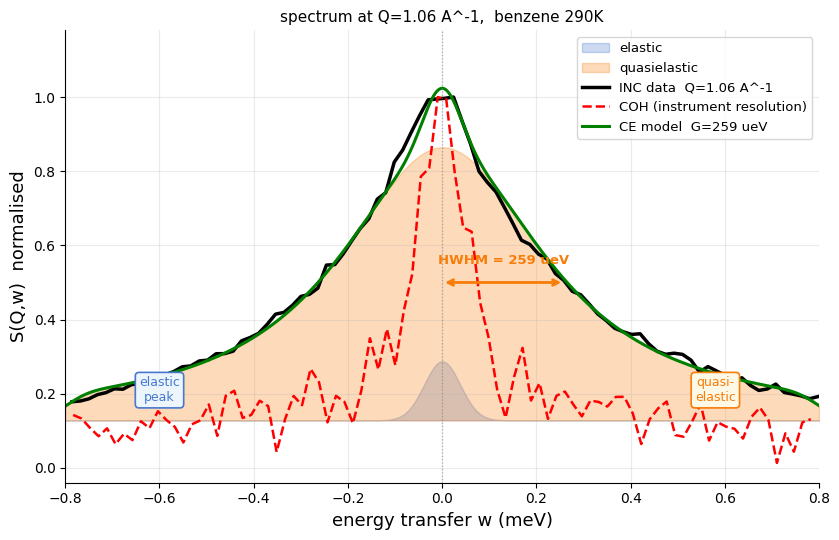

In [17]:
Q_target = 1.06

good = d_inc['good'];  Q_g = d_inc['Q'][good]
emask = (d_inc['e'] >= -0.8) & (d_inc['e'] <= 0.8)
ew = d_inc['e'][emask];  sr = d_inc['sigma_res']


# average a few detectors near Q_target
near = np.where(np.abs(Q_g - Q_target) < 0.10)[0]
if len(near) == 0:
    near = np.argsort(np.abs(Q_g - Q_target))[:4]
spec = np.nanmean([d_inc['data'][good[j]][emask] for j in near], axis=0)
spec = np.where(np.isfinite(spec), spec, 0);  spec /= spec.max()


# same Q slice from the COH file
gc  = d_coh['good'];  Qc = d_coh['Q'][gc]
emkc = (d_coh['e'] >= -0.8) & (d_coh['e'] <= 0.8);  ec = d_coh['e'][emkc]
nrc  = np.where(np.abs(Qc - Q_target) < 0.10)[0]
if len(nrc) == 0:
    nrc = np.argsort(np.abs(Qc - Q_target))[:4]
res_spec = np.nanmean([d_coh['data'][gc[j]][emkc] for j in nrc], axis=0)
res_spec = np.where(np.isfinite(res_spec), res_spec, 0)
rsn = res_spec / res_spec.max() if res_spec.max() > 0 else res_spec


# CE model at this Q
wf    = np.linspace(-0.8, 0.8, 1000)
Gamma = CE(Q_target, D_map, l_map)
dt    = wf[1] - wf[0]
el    = gnorm(wf, sr);  el /= el.max()
ql_r  = fftconvolve(lorentz(wf, Gamma), gnorm(wf, sr), mode='same') * dt
ql    = ql_r / ql_r.max() if ql_r.max() > 0 else ql_r
amp, _ = nnls(np.column_stack([el, ql, np.ones(len(wf))]), np.interp(wf, ew, spec))
model  = amp[0]*el + amp[1]*ql + amp[2]


fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.fill_between(wf, amp[2], amp[0]*el+amp[2], alpha=0.28, color='#4878CF', label='elastic')
ax.fill_between(wf, amp[2], amp[1]*ql+amp[2], alpha=0.28, color='#F87C08', label='quasielastic')
ax.plot(ew,  spec,  'k-',  lw=2.5, label=f'INC data  Q={Q_target:.2f} A^-1')
ax.plot(ec,  rsn,   'r--', lw=1.8, label='COH (instrument resolution)')
ax.plot(wf,  model, 'g-',  lw=2.2, label=f'CE model  G={Gamma*1000:.0f} ueV')
ax.axvline(0, color='gray', lw=0.9, ls=':', alpha=0.6)


ax.annotate('', xy=(Gamma, 0.50), xytext=(0, 0.50),
            arrowprops=dict(arrowstyle='<->', color='#F87C08', lw=2.0))

ax.text(Gamma/2, 0.55, f'HWHM = {Gamma*1000:.0f} ueV',
        ha='center', color='#F87C08', fontsize=9.5, fontweight='bold')

ax.text(-0.60, 0.18, 'elastic\npeak', ha='center', fontsize=9, color='#4878CF',
        bbox=dict(boxstyle='round', fc='#EBF5FB', ec='#4878CF', lw=1.2))

ax.text( 0.58, 0.18, 'quasi-\nelastic', ha='center', fontsize=9, color='#F87C08',
        bbox=dict(boxstyle='round', fc='#FEF9E7', ec='#F87C08', lw=1.2))


ax.set_xlabel('energy transfer w (meV)', fontsize=13)
ax.set_ylabel('S(Q,w)  normalised', fontsize=13)
ax.set_title(f'spectrum at Q={Q_target:.2f} A^-1,  benzene 290K', fontsize=11)
ax.legend(fontsize=9.5)
ax.set_xlim(-0.8, 0.8);  ax.set_ylim(-0.04, 1.18)
ax.grid(True, alpha=0.25)
ax.spines['top'].set_visible(False);  ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig1_spectrum.pdf'), bbox_inches='tight')
plt.show()


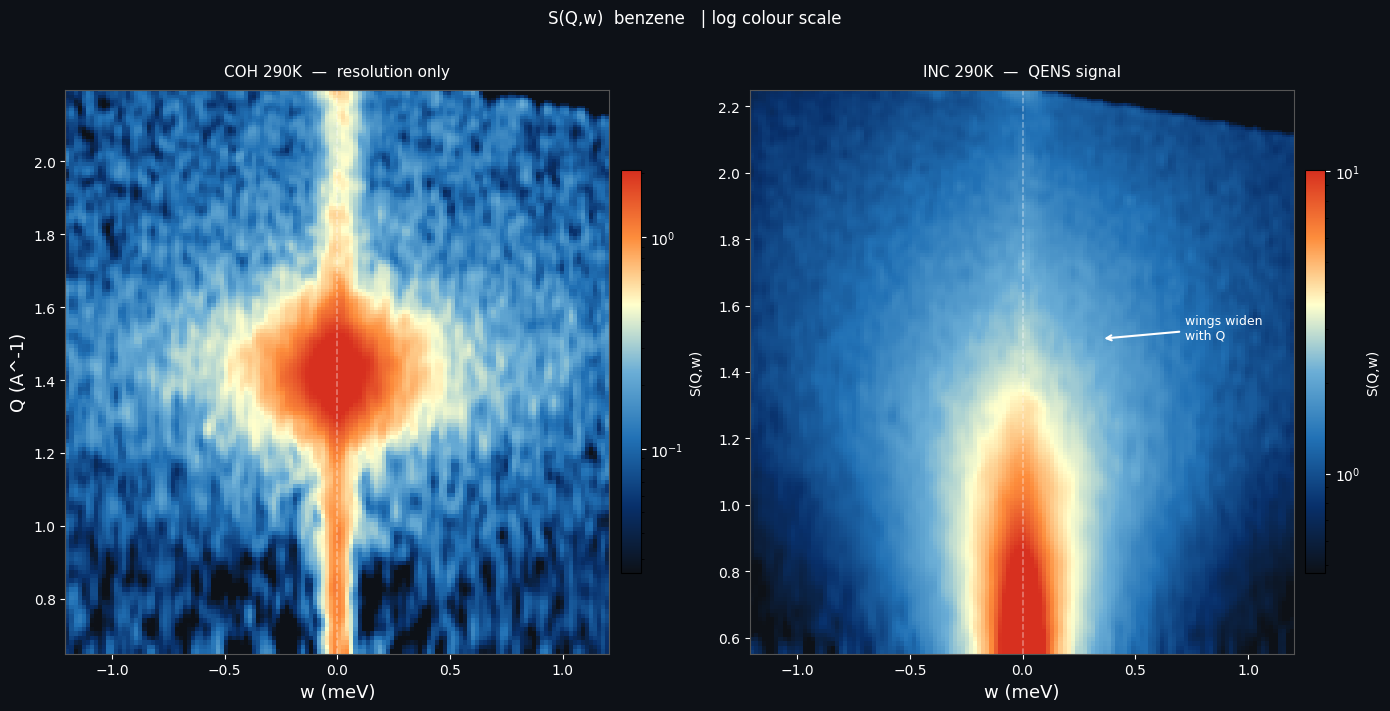

In [ ]:
CMAP = LinearSegmentedColormap.from_list('qens',
    ['#0d1117','#08306b','#2171b5','#6baed6','#ffffcc','#fd8d3c','#d7301f'], N=512)


fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('#0d1117')


for ax, (d, title) in zip(axes, [(d_coh, 'COH 290K  —  resolution only'),
                                 (d_inc, 'INC 290K  —  QENS signal'),]):
    

    g    = d['good'];  Q_g = d['Q'][g];  e = d['e']
    emask = (e >= -1.2) & (e <= 1.2)
    img   = d['data'][np.ix_(g, emask)]
    img   = np.where(np.isfinite(img) & (img > 0), img, np.nan)



    qs    = np.argsort(Q_g)  # sort by Q so the map looks clean
    ism   = gaussian_filter(np.where(np.isfinite(img[qs]), img[qs], 0), sigma=[1.5, 0.8])
    ism[ism <= 0] = np.nan


    vmin = np.nanpercentile(ism, 2)
    vmax = np.nanpercentile(ism, 99)
    im   = ax.pcolormesh(e[emask], Q_g[qs], ism, cmap=CMAP,
                         norm=LogNorm(vmin=max(vmin, 1e-6), vmax=vmax),
                         shading='auto', rasterized=True)
    
    ax.axvline(0, color='white', lw=1.1, ls='--', alpha=0.4)
    ax.set_xlabel('w (meV)', color='white', fontsize=13)
    ax.set_title(title, color='white', fontsize=11, pad=10)
    ax.tick_params(colors='white');  ax.set_facecolor('#0d1117')

    for sp in ax.spines.values():
        sp.set_edgecolor('#555')

    cb = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.035)
    cb.set_label('S(Q,w)', color='white', fontsize=10)
    cb.ax.yaxis.set_tick_params(color='white')

    plt.setp(cb.ax.yaxis.get_ticklabels(), color='white')



axes[0].set_ylabel('Q (A^-1)', color='white', fontsize=13)
axes[1].annotate('wings widen\nwith Q', xy=(0.35, 1.5), xytext=(0.72, 1.5),
                 color='white', fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='white', lw=1.5))



fig.suptitle('S(Q,w)  benzene ',
             color='white', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig2_map.pdf'), bbox_inches='tight', facecolor='#0d1117')
plt.show()


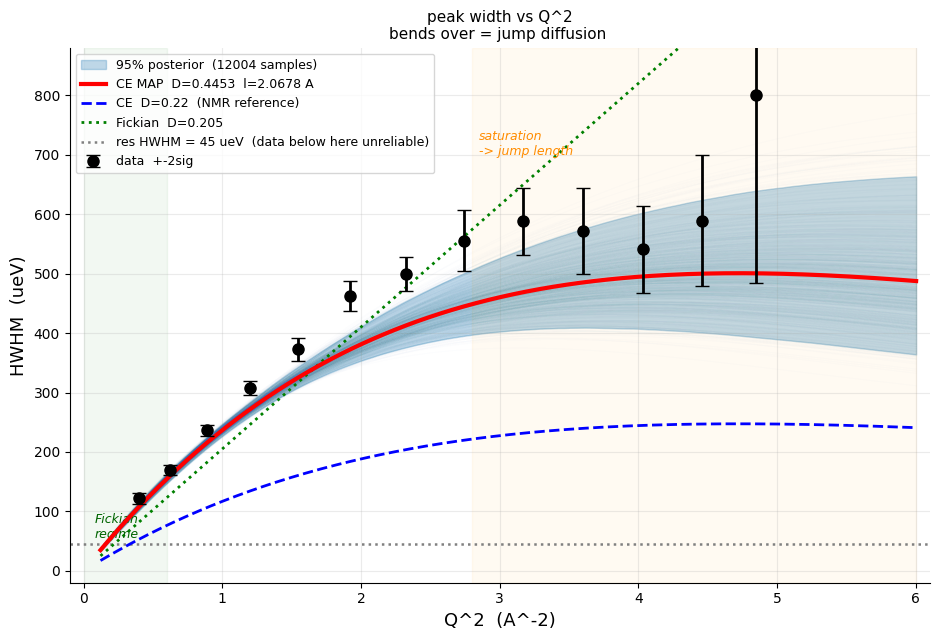

In [26]:
Q_fine  = np.linspace(0.35, 2.45, 400)
Q2_fine = Q_fine**2
Q2_data = Q_hwhm**2



fig, ax = plt.subplots(figsize=(9.5, 6.5))



# draw 600 CE curves sampled from the posterior
rng   = np.random.default_rng(42)
idx_f = rng.choice(len(D_s), 600, replace=False)


for i in idx_f:
    ax.plot(Q2_fine, CE(Q_fine, D_s[i], l_s[i])*1000, color='#1f77b4', alpha=0.012, lw=0.8)



# shaded 95% band
G_fan = np.array([CE(Q_fine, D_s[i], l_s[i])*1000 for i in range(len(D_s))])

ax.fill_between(Q2_fine,
                np.percentile(G_fan, 2.5, axis=0),
                np.percentile(G_fan, 97.5, axis=0),
                alpha=0.28, color='#1f77b4', label=f'95% posterior  ({len(D_s)} samples)')

ax.plot(Q2_fine, CE(Q_fine, D_map, l_map)*1000, 'r-', lw=3.0, zorder=4,
        label=f'CE MAP  D={D_map:.4f}  l={l_map:.4f} A')

ax.plot(Q2_fine, CE(Q_fine, 0.22, l_map)*1000, 'b--', lw=2.0, zorder=3,
        label='CE  D=0.22  (NMR reference)')

ax.plot(Q2_fine, Fickian(Q_fine, 0.205)*1000, 'g:', lw=2.0, zorder=3,
        label='Fickian  D=0.205')

ax.errorbar(Q2_data, G_hwhm*1000, yerr=2*G_err*1000,
            fmt='ko', ms=8, capsize=5, elinewidth=2, label='data  +-2sig', zorder=6)


res_hwhm = d_inc['fwhm_res'] / 2 * 1000
ax.axhline(res_hwhm, color='gray', ls=':', lw=1.8,
           label=f'res HWHM = {res_hwhm:.0f} ueV  (data below here unreliable)')


ax.axvspan(0, 0.6, alpha=0.05, color='green')
ax.text(0.08, 55, 'Fickian\nregime', color='darkgreen', fontsize=9, style='italic')
ax.axvspan(2.8, Q2_fine[-1], alpha=0.05, color='orange')
ax.text(2.85, 700, 'saturation\n-> jump length', color='darkorange', fontsize=9, style='italic')




ax.set_xlabel('Q^2  (A^-2)', fontsize=13)
ax.set_ylabel('HWHM  (ueV)', fontsize=13)
ax.set_title('peak width vs Q^2\n'
             'bends over = jump diffusion ', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(-0.1, Q2_fine[-1]+0.1);  ax.set_ylim(-20, 880)
ax.grid(True, alpha=0.25)
ax.spines['top'].set_visible(False);  ax.spines['right'].set_visible(False)


plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig3_hwhm.pdf'), bbox_inches='tight')
plt.show()


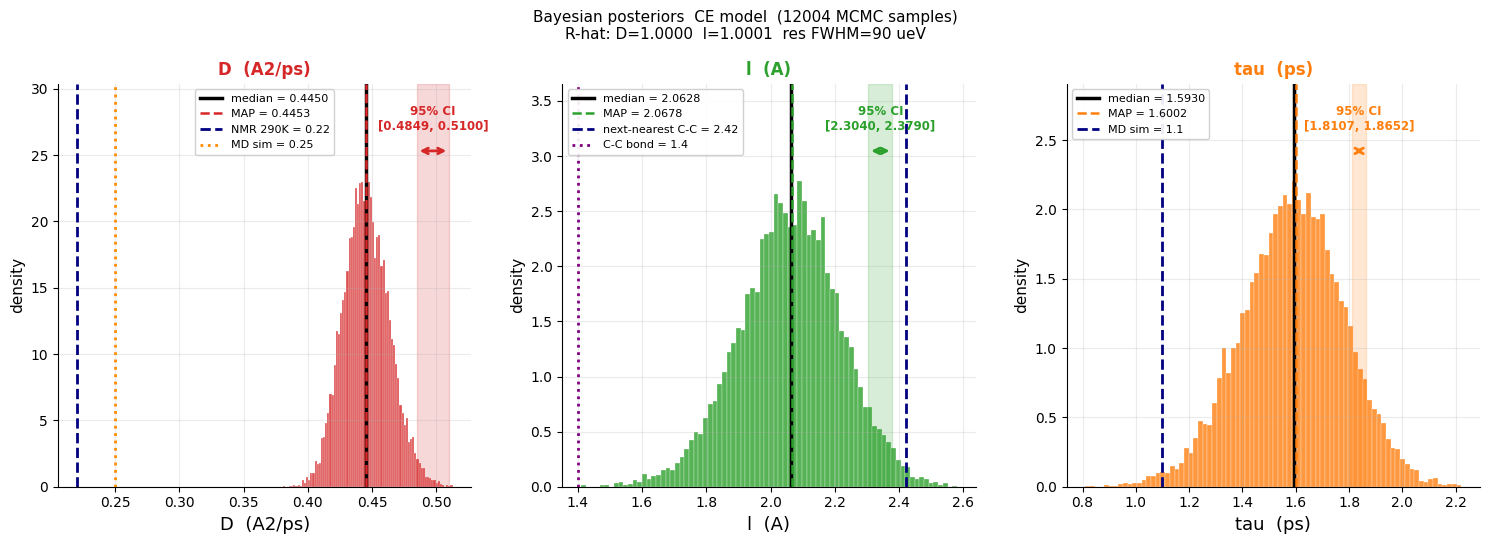

In [20]:
tau_s = l_s**2 / (6 * D_s)


param_cfg = [(D_s,   D_map,   0.484891, 0.510012,   'D  (A2/ps)', '#d62728',
            [(0.22, 'NMR 290K', 'navy', '--'), (0.25, 'MD sim', 'darkorange', ':')]),
            (l_s,   l_map,   2.304007, 2.379010,   'l  (A)',     '#2ca02c',
            [(2.42, 'next-nearest C-C', 'navy', '--'), (1.40, 'C-C bond', 'purple', ':')]),
            (tau_s, tau_map, 1.810701, 1.865163,   'tau  (ps)',  '#ff7f0e',
            [(1.10, 'MD sim', 'navy', '--')]),]




fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.suptitle(f'Bayesian posteriors  CE model  ({len(D_s)} MCMC samples)\n'
    f'R-hat: D={Rhat_D:.4f}  l={Rhat_l:.4f}  '
    f'res FWHM={d_inc["fwhm_res"]*1000:.0f} ueV',
    fontsize=11)





for ax, (arr, MAP, lo, hi, xlabel, col, refs) in zip(axes, param_cfg):
    med = np.median(arr)
    cnt, _, _ = ax.hist(arr, bins=80, density=True,
                        color=col, alpha=0.80, edgecolor='white', lw=0.25)
    pk = cnt.max()


    ax.axvspan(lo, hi, alpha=0.18, color=col)
    ax.axvline(med, color='black', lw=2.5, label=f'median = {med:.4f}')
    ax.axvline(MAP, color=col,    lw=1.8, ls='--', label=f'MAP = {MAP:.4f}')
    for val, lbl, lc, ls in refs:
        ax.axvline(val, color=lc, lw=2.0, ls=ls, label=f'{lbl} = {val}')


    ax.annotate('', xy=(hi, pk*1.10), xytext=(lo, pk*1.10),
                arrowprops=dict(arrowstyle='<->', color=col, lw=2.0))
    ax.text((lo+hi)/2, pk*1.17, f'95% CI\n[{lo:.4f}, {hi:.4f}]',
            ha='center', fontsize=8.5, color=col, fontweight='bold')


    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_ylabel('density', fontsize=11)
    ax.set_title(xlabel, fontsize=12, color=col, fontweight='bold')
    ax.legend(fontsize=8, framealpha=0.92)
    ax.set_ylim(0, pk * 1.32)
    ax.grid(True, alpha=0.25)
    ax.spines['top'].set_visible(False);  ax.spines['right'].set_visible(False)




plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig4_posteriors.pdf'), bbox_inches='tight')
plt.show()


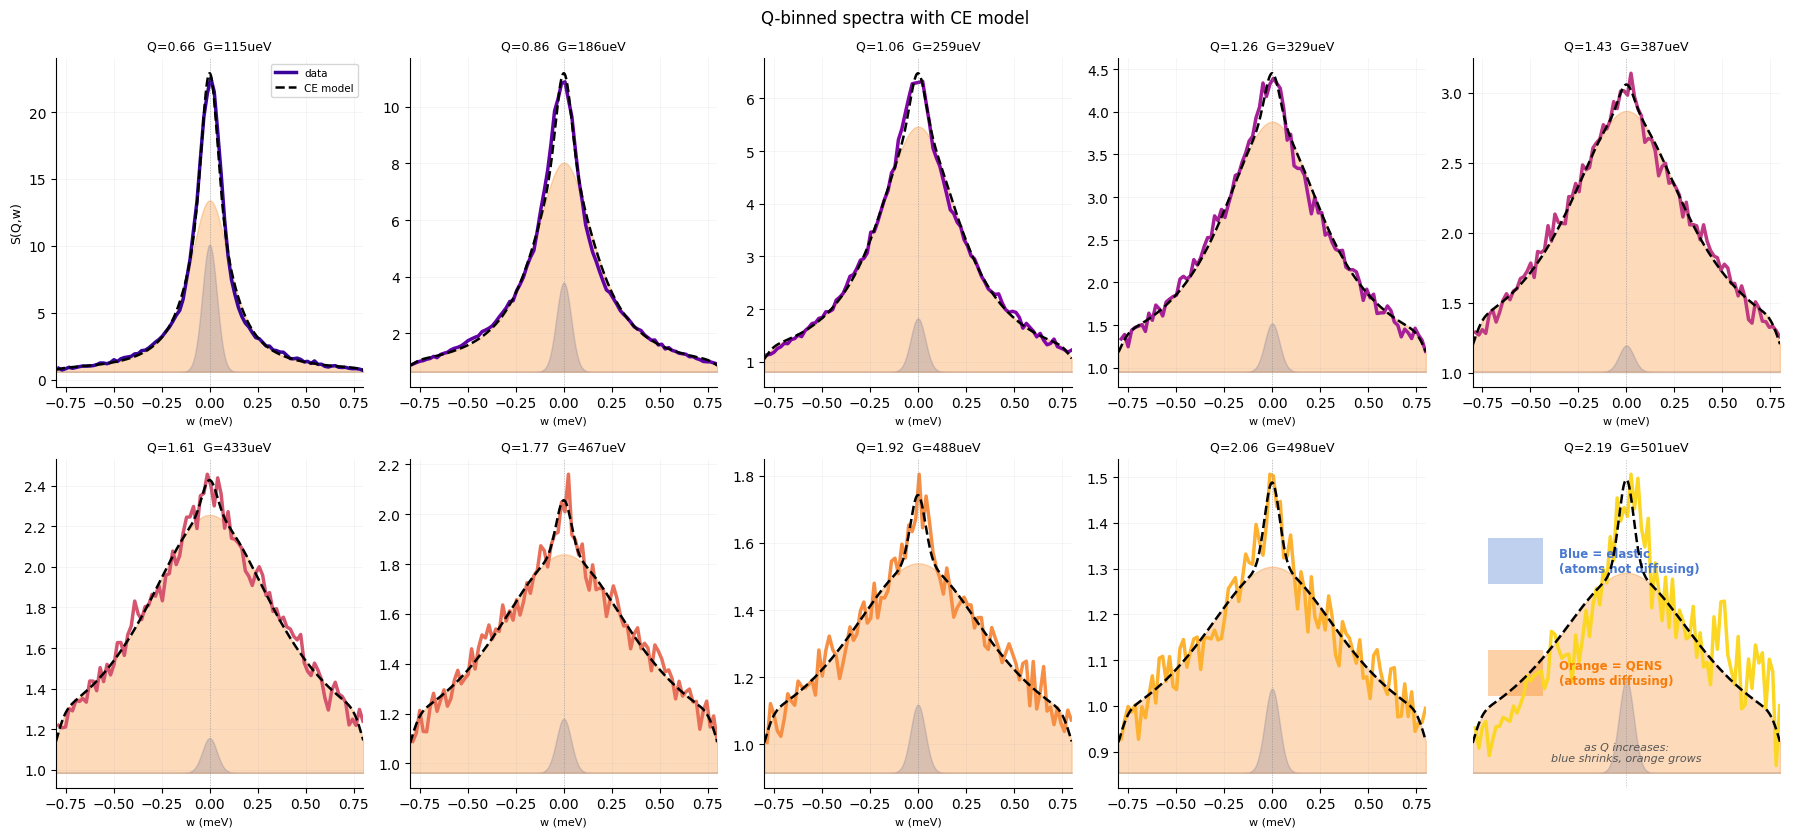

In [21]:
n_bins  = 10
good    = d_inc['good'];  Q_g = d_inc['Q'][good]
emask   = (d_inc['e'] >= -0.8) & (d_inc['e'] <= 0.8)
ew      = d_inc['e'][emask];  sr = d_inc['sigma_res']
Q_edges = np.percentile(Q_g, np.linspace(0, 100, n_bins + 1))
cmap_q  = plt.cm.plasma(np.linspace(0.08, 0.92, n_bins))
wm      = np.linspace(-0.8, 0.8, 900);  dtm = wm[1] - wm[0]


fig, axes = plt.subplots(2, 5, figsize=(18, 8.5))
flat = axes.flatten()





for k in range(n_bins):
    ax  = flat[k]
    idx = np.where((Q_g >= Q_edges[k]) & (Q_g < Q_edges[k+1]))[0]
    if len(idx) == 0:
        ax.axis('off')
        continue


    sp   = np.nanmean([d_inc['data'][good[j]][emask] for j in idx], axis=0)
    sp   = np.where(np.isfinite(sp), sp, 0)
    Qmid = Q_g[idx].mean()
    Gam  = CE(Qmid, D_map, l_map)


    el_m = gnorm(wm, sr);  el_m /= el_m.max()
    ql_r = fftconvolve(lorentz(wm, Gam), gnorm(wm, sr), mode='same') * dtm
    ql_m = ql_r / ql_r.max() if ql_r.max() > 0 else ql_r
    amp, _ = nnls(np.column_stack([el_m, ql_m, np.ones(len(wm))]),
                  np.interp(wm, ew, sp))
    model = amp[0]*el_m + amp[1]*ql_m + amp[2]


    ax.fill_between(wm, amp[2], amp[0]*el_m+amp[2], alpha=0.28, color='#4878CF')
    ax.fill_between(wm, amp[2], amp[1]*ql_m+amp[2], alpha=0.28, color='#F87C08')
    ax.plot(ew,  sp,    color=cmap_q[k], lw=2.5, label='data')
    ax.plot(wm,  model, 'k--', lw=1.8, label='CE model', zorder=5)
    ax.axvline(0, color='gray', lw=0.7, ls=':', alpha=0.5)


    ax.set_title(f'Q={Qmid:.2f}  G={Gam*1000:.0f}ueV', fontsize=9)
    ax.set_xlim(-0.8, 0.8);  ax.set_xlabel('w (meV)', fontsize=8)
    ax.grid(True, alpha=0.18, lw=0.5)
    ax.spines['top'].set_visible(False);  ax.spines['right'].set_visible(False)
    if k == 0:
        ax.set_ylabel('S(Q,w)', fontsize=9)
        ax.legend(fontsize=7.5)






# use the last panel as a key
flat[9].axis('off')
for y, col, txt in [(0.62, '#4878CF', 'Blue = elastic\n(atoms not diffusing)'),
                    (0.28, '#F87C08', 'Orange = QENS\n(atoms diffusing)'),]:

    flat[9].add_patch(plt.Rectangle((0.05, y), 0.18, 0.14,fc=col, alpha=0.35, transform=flat[9].transAxes))
    
    flat[9].text(0.28, y+0.07, txt, transform=flat[9].transAxes,fontsize=8.5, color=col, fontweight='bold', va='center')

flat[9].text(0.5, 0.08, 'as Q increases:\nblue shrinks, orange grows',ha='center', transform=flat[9].transAxes,
             fontsize=8, color='#555', style='italic')





fig.suptitle('Q-binned spectra with CE model', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig5_overlay.pdf'), bbox_inches='tight')
plt.show()
